#Lab Activity 04

A **Self-Organising Map (SOM)** is an unsupervised network that maps
high-dimensional data onto a low-dimensional grid — usually a 2-D lattice of
`m x n` neurons — while preserving the topology of the input space. Neurons that
end up next to each other on the map respond to similar inputs.

These activities build a SOM from scratch and train it on the Iris dataset.

##Activity 1: Data pre-processing

The SOM compares inputs to weights using **Euclidean distance**, so features
with a larger range would dominate that distance. `MinMaxScaler` rescales every
feature to the range 0–1, which is also the range the weights are initialised
in.

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler

# Load Iris dataset
data = datasets.load_iris()
X = data.data

# Normalize the dataset
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Shape        :", X_scaled.shape)
print("Feature range:", X_scaled.min(axis=0), "to", X_scaled.max(axis=0))

Shape        : (150, 4)
Feature range: [0. 0. 0. 0.] to [1. 1. 1. 1.]


##Activity 2: Implementing SOM

The class holds one weight vector per neuron, so `weights` has shape
`(m, n, dim)`. Training has two phases per input:

* **Competition** — `_find_bmu` measures the distance from the input to every
  neuron and returns the closest one, the **Best Matching Unit (BMU)**.
* **Adaptation** — `_update_weights` moves the BMU *and its neighbours* towards
  the input. How much each neuron moves depends on how far it sits from the BMU
  **on the grid**, not in the data.

Both the learning rate and the neighbourhood radius `sigma` decay as training
goes on, so the map makes large, coarse adjustments early and fine ones
later.

In [2]:
class SOM:
    def __init__(self, m, n, dim, learning_rate=0.5, sigma=None):
        self.m = m
        self.n = n
        self.dim = dim
        self.learning_rate = learning_rate
        self.sigma = sigma if sigma else max(m, n) / 2.0
        self.weights = np.random.rand(m, n, dim)

    def _find_bmu(self, x):
        distances = np.linalg.norm(self.weights - x, axis=-1)
        bmu_index = np.unravel_index(np.argmin(distances), (self.m, self.n))
        return bmu_index

    def _update_weights(self, x, bmu, iteration, max_iter):
        learning_rate = self.learning_rate * np.exp(-iteration / max_iter)
        sigma = self.sigma * np.exp(-iteration / max_iter)
        for i in range(self.m):
            for j in range(self.n):
                w = self.weights[i, j]
                distance = np.linalg.norm(np.array([i, j]) - np.array(bmu))
                if distance < sigma:
                    influence = np.exp(-distance / (2 * (sigma ** 2)))
                    self.weights[i, j] += influence * learning_rate * (x - w)

    def train(self, X, num_iterations):
        for iteration in range(num_iterations):
            for x in X:
                bmu = self._find_bmu(x)
                self._update_weights(x, bmu, iteration, num_iterations)


print("SOM class defined.")

SOM class defined.


##Activity 3: Training the SOM

A 10x10 grid of neurons, each holding a 4-value weight vector — one value per
Iris feature. The seed is fixed so the random starting weights, and every result
below, are the same on each run.

This cell takes a few seconds: the update loops over all 100 neurons in Python
for every one of the 150 samples, on each of the 100 iterations.

In [3]:
np.random.seed(1)

som = SOM(m=10, n=10, dim=4, learning_rate=0.5)
som.train(X_scaled, num_iterations=100)

print("Weight grid shape:", som.weights.shape)
print("Initial sigma    :", som.sigma)

Weight grid shape: (10, 10, 4)
Initial sigma    : 5.0


##Activity 4: Visualization

Iris has 4 features and the weights were scaled to 0–1, so each neuron's weight
vector can be read directly as an **RGBA colour**. Neurons holding similar
weights come out in similar colours, and the smooth colour gradient across the
grid is the topology preservation the SOM is supposed to produce.

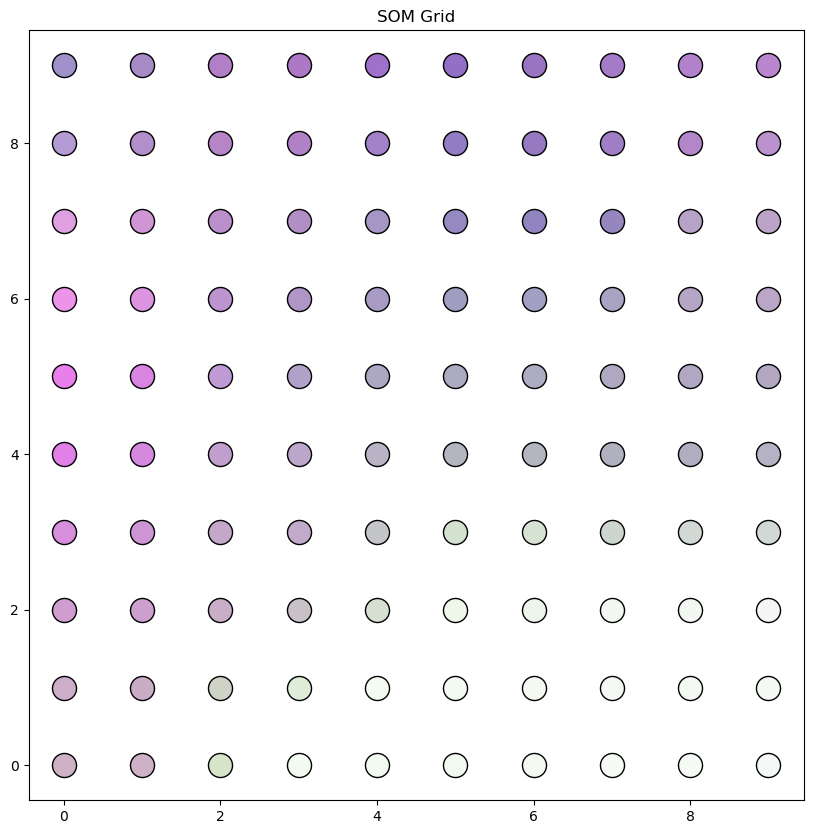

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_som(som):
    plt.figure(figsize=(10, 10))
    for i in range(som.m):
        for j in range(som.n):
            # The weight vector is wrapped in a list so matplotlib reads it as
            # one RGBA colour rather than as four separate colour values.
            plt.scatter(j, i, c=[som.weights[i, j]], marker='o', s=300, edgecolor='k')
    plt.title('SOM Grid')
    plt.show()

plot_som(som)

##Activity 5: Clustering with SOM

Once trained, the map is used as a clustering model: each sample is assigned to
the neuron that matches it best. The BMU coordinates are the cluster label — two
samples with the same BMU landed in the same cluster.

In [5]:
def get_cluster_labels(som, X):
    cluster_labels = []
    for x in X:
        bmu = som._find_bmu(x)
        cluster_labels.append(bmu)
    return np.array(cluster_labels)

cluster_labels = get_cluster_labels(som, X_scaled)
print(cluster_labels)

[[1 6]
 [2 8]
 [0 8]
 [1 9]
 [0 5]
 [0 3]
 [0 7]
 [1 6]
 [2 9]
 [2 8]
 [1 4]
 [0 7]
 [2 8]
 [0 9]
 [0 3]
 [0 3]
 [0 3]
 [1 6]
 [0 3]
 [1 4]
 [2 6]
 [0 5]
 [0 6]
 [2 6]
 [0 7]
 [2 8]
 [2 6]
 [2 5]
 [2 6]
 [0 8]
 [1 8]
 [2 6]
 [0 3]
 [0 3]
 [2 8]
 [2 7]
 [2 5]
 [0 6]
 [0 9]
 [1 6]
 [0 6]
 [3 9]
 [0 9]
 [2 6]
 [0 4]
 [2 8]
 [1 4]
 [0 8]
 [1 4]
 [1 7]
 [0 0]
 [1 1]
 [1 0]
 [6 9]
 [3 2]
 [5 6]
 [5 4]
 [4 8]
 [2 2]
 [6 7]
 [4 9]
 [5 5]
 [7 9]
 [3 3]
 [4 6]
 [0 1]
 [5 5]
 [6 8]
 [9 9]
 [6 9]
 [6 4]
 [2 2]
 [8 8]
 [3 3]
 [2 2]
 [1 1]
 [2 1]
 [2 0]
 [5 5]
 [6 9]
 [6 9]
 [6 9]
 [7 8]
 [8 7]
 [6 6]
 [5 4]
 [1 0]
 [8 9]
 [4 5]
 [6 8]
 [6 8]
 [4 4]
 [7 8]
 [4 8]
 [6 7]
 [4 5]
 [5 6]
 [2 2]
 [4 8]
 [5 6]
 [9 0]
 [8 6]
 [5 1]
 [5 2]
 [9 3]
 [5 0]
 [7 7]
 [4 0]
 [4 1]
 [7 0]
 [7 3]
 [8 4]
 [7 2]
 [9 6]
 [9 5]
 [9 1]
 [5 2]
 [7 0]
 [5 0]
 [9 9]
 [8 1]
 [7 5]
 [5 0]
 [9 7]
 [7 2]
 [6 1]
 [9 7]
 [6 4]
 [9 4]
 [3 0]
 [4 0]
 [7 0]
 [9 4]
 [4 2]
 [9 8]
 [6 0]
 [9 0]
 [5 2]
 [6 4]
 [7 2]
 [9 2]
 [9 2]
 [8 6]

###Checking the clusters against the true species

The SOM never saw the species labels. Counting which species landed on each
neuron shows whether the unsupervised map still separated them.

In [6]:
unique_neurons = np.unique(cluster_labels, axis=0)
print("Distinct neurons used:", len(unique_neurons), "of", som.m * som.n)

print("\nSpecies per neuron (only neurons that were hit):")
for neuron in unique_neurons:
    mask = (cluster_labels == neuron).all(axis=1)
    species, counts = np.unique(data.target[mask], return_counts=True)
    names = ", ".join(f"{data.target_names[s]}={c}" for s, c in zip(species, counts))
    print(f"  neuron ({neuron[0]}, {neuron[1]}): {names}")

Distinct neurons used: 72 of 100

Species per neuron (only neurons that were hit):
  neuron (0, 0): versicolor=1
  neuron (0, 1): versicolor=1
  neuron (0, 3): setosa=7
  neuron (0, 4): setosa=1
  neuron (0, 5): setosa=2
  neuron (0, 6): setosa=3
  neuron (0, 7): setosa=3
  neuron (0, 8): setosa=3
  neuron (0, 9): setosa=3
  neuron (1, 0): versicolor=2
  neuron (1, 1): versicolor=2
  neuron (1, 4): setosa=4
  neuron (1, 6): setosa=4
  neuron (1, 7): setosa=1
  neuron (1, 8): setosa=1
  neuron (1, 9): setosa=1
  neuron (2, 0): versicolor=1
  neuron (2, 1): versicolor=1
  neuron (2, 2): versicolor=4
  neuron (2, 5): setosa=2
  neuron (2, 6): setosa=6
  neuron (2, 7): setosa=1
  neuron (2, 8): setosa=6
  neuron (2, 9): setosa=1
  neuron (3, 0): virginica=1
  neuron (3, 2): versicolor=1
  neuron (3, 3): versicolor=2
  neuron (3, 9): setosa=1
  neuron (4, 0): virginica=2
  neuron (4, 1): virginica=1
  neuron (4, 2): virginica=1
  neuron (4, 4): versicolor=1
  neuron (4, 5): versicolor=2
  n

#End!